In [1]:
# %load_ext autoreload
# %autoreload 2
import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from TorchDiffEqPack import odesolve
from torchdiffeq import odeint_adjoint as odeint

import matplotlib as mpl
import seaborn as sns

/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
main_dir="/home/wergillius/Project/PINN_dynamics"
os.chdir(main_dir)

In [3]:
ckpt_path = "logs/tom_pos-DM_scaled_n9/pde_params_tsense/lightning_logs/golden-version-old0/checkpoints/epoch=174-total_loss=0.88114280.ckpt"
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")

# # MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path, map_location="cuda:0")
device = pde_model.device

In [17]:
data_name = 'tom_pos'
cellstate_key = 'DM_scaled'
timepoint_key = 'timepoint_tx_days'
n_dimension = 30 
ct_key = 'anno_man'

In [18]:
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

In [19]:
cellstate = adata.obsm[cellstate_key][:,:n_dimension]

In [20]:
cellstate = adata.obsm[cellstate_key][:,:n_dimension]
log_u, density_fns = tl.compute_mellon_u(adata, cellstate_key, timepoint_key=timepoint_key, n_dimension = n_dimension)
predictors = [model.predict for model in density_fns]

dloguds_mellon = np.stack([pdtr.gradient(cellstate) for pdtr in predictors])
print(dloguds_mellon.shape)

estimating density for time  3
[2024-12-09 09:25:07,780] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (394) >= n_samples (394) and rank = 1.0.
[2024-12-09 09:25:07,781] [INFO    ] Computing nearest neighbor distances.
[2024-12-09 09:25:07,833] [INFO    ] Using embedding dimensionality d=30. Use d_method="fractal" to enable effective density normalization.
[2024-12-09 09:25:07,834] [INFO    ] Using covariance function Matern52(ls=0.5021298532406172).
[2024-12-09 09:25:07,893] [INFO    ] Using rank 394 covariance representation.
[2024-12-09 09:25:07,904] [INFO    ] Running inference using L-BFGS-B.
[2024-12-09 09:25:08,757] [INFO    ] Computing predictive function.


estimating density for time  7
[2024-12-09 09:25:09,437] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (633) >= n_samples (633) and rank = 1.0.
[2024-12-09 09:25:09,438] [INFO    ] Computing nearest neighbor distances.
[2024-12-09 09:25:09,494] [INFO    ] Using embedding dimensionality d=30. Use d_method="fractal" to enable effective density normalization.
[2024-12-09 09:25:09,495] [INFO    ] Using covariance function Matern52(ls=0.4733215610570367).
[2024-12-09 09:25:09,560] [INFO    ] Using rank 633 covariance representation.
[2024-12-09 09:25:09,580] [INFO    ] Running inference using L-BFGS-B.
[2024-12-09 09:25:10,441] [INFO    ] Computing predictive function.
estimating density for time  12
[2024-12-09 09:25:11,162] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (613) >= n_samples (613) and rank = 1.0.
[2024-12-09 09:25:11,163] [INFO    ] Computing nearest neighbor distances.
[2024-12-09 09:25:11,217] [INFO    ] Using embedding dimensionality d=30.

In [21]:
dloguds_mellon.shape

(9, 49390, 30)

In [22]:
np.save('data/tom_pos_mellon_dloguds.npy',dloguds_mellon)

In [26]:
timepoints

array([  3,   7,  12,  27,  49,  76, 112, 161, 269])

In [ ]:
for i,p in enumerate(predictors):
    p.to_json(f"data/tom_pos_mellon_day{timepoints[i]}_predictor.json") 

[2024-12-09 09:43:53,087] [INFO    ] Written predictor to data/tom_pos_mellon_day3_predictor.json.
[2024-12-09 09:43:53,103] [INFO    ] Written predictor to data/tom_pos_mellon_day7_predictor.json.
[2024-12-09 09:43:53,116] [INFO    ] Written predictor to data/tom_pos_mellon_day12_predictor.json.
[2024-12-09 09:43:53,185] [INFO    ] Written predictor to data/tom_pos_mellon_day27_predictor.json.
[2024-12-09 09:43:53,272] [INFO    ] Written predictor to data/tom_pos_mellon_day49_predictor.json.
[2024-12-09 09:43:53,375] [INFO    ] Written predictor to data/tom_pos_mellon_day76_predictor.json.
[2024-12-09 09:43:53,478] [INFO    ] Written predictor to data/tom_pos_mellon_day112_predictor.json.
[2024-12-09 09:43:53,583] [INFO    ] Written predictor to data/tom_pos_mellon_day161_predictor.json.
[2024-12-09 09:43:53,684] [INFO    ] Written predictor to data/tom_pos_mellon_day269_predictor.json.


In [23]:
DS_full = reader.Duds_AnnDS(
                            AnnData=adata, 
                            timepoint_idx=[0,2,4,6], 
                            precomputed_duds=dloguds_mellon,
                            timepoint_key = timepoint_key,
                            n_dimension = n_dimension,
                            cellstate_key=cellstate_key,  #'DM_EigenVector'
                            log_transform=True,
                            norm_time=False,
                            deltax_key="Delta_DM",
                            density_funs = np.array(predictors),
                            batchsize=100)

# adata
t7_ad = DS_full.adata.copy()
duds = DS_full.duds.copy()
u_b = DS_full.u_b.cpu().numpy().reshape(DS_full.T_b.shape[0], -1)
cellstate = torch.from_numpy(DS_full.cellstate).float()
timepoint_label = DS_full.popD['t']

Computing density :
using pre-defined density fun `<class 'mellon.conditional.FullConditional'>`


/home/wergillius/Project/PINN_dynamics/PINN/reader.py:182: RuntimeWarning: invalid value encountered in sqrt
  scaled_P = self.density_P.flatten() ** self.resampling_indensity


In [28]:
PINN.pl.params_in_umap(t7_ad, log_u, param='log u')

prediction of shape (9, 49390)


ValueError: Length of values (49390) does not match length of index (25948)

prediction of shape (4, 25948)


(<Figure size 1080x200 with 8 Axes>,
 array([<Axes: title={'center': 'Day3_log u\nmin:-8.17e+01\nmax:-4.65e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day12_log u\nmin:-9.66e+01\nmax:-4.80e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day49_log u\nmin:-1.19e+02\nmax:-5.63e-01'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day112_log u\nmin:-1.22e+02\nmax:2.07e+00'}, xlabel='UMAP1', ylabel='UMAP2'>],
       dtype=object))

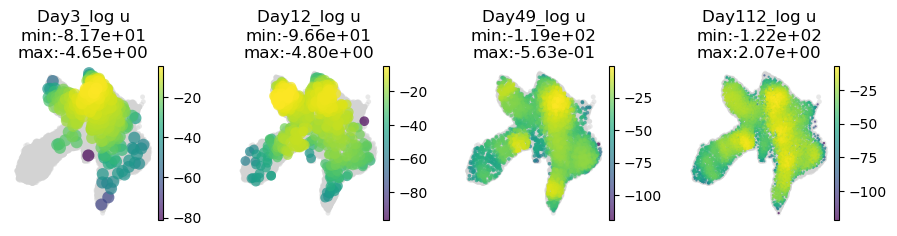

In [ ]:
PINN.pl.params_in_umap(t7_ad, u_b, timepoints=timepoint_label, param='log u')

In [25]:
DS_full.deltax.shape

(25948, 30)

In [10]:
# detecting pre-computed duds
duds_path = f"data/{data_name}_duds.npy"
precomputed_duds = np.load(duds_path)

DS_full = reader.Duds_AnnDS(
                            AnnData=adata, 
                            timepoint_idx=None, 
                            precomputed_duds=precomputed_duds,
                            timepoint_key = timepoint_key,
                            n_dimension = n_dimension,
                            cellstate_key=cellstate_key,  #'DM_EigenVector'
                            log_transform=False,
                            norm_time=False,
                            deltax_key="Delta_DM",
                            density_funs = None,
                            # base_cellstate = base_cellstate,
                            batchsize=100)

# adata
t7_ad = DS_full.adata.copy()
duds = DS_full.duds.copy()
u_b = DS_full.u_b.cpu().numpy().reshape(DS_full.T_b.shape[0], -1)
cellstate = torch.from_numpy(DS_full.cellstate).float()
timepoint_label = DS_full.popD['t']

Computing density :
`density_funs` not specified, use gaussian kde


In [11]:
cellstate.shape

torch.Size([49390, 10])

In [62]:
u_t_ls = []
dloguds_ls = []
chunk_size = 5000

s_ts = DS_full.s.float()
t_ts = DS_full.t_b.float()

for i in range(0, len(t_ts), chunk_size):

    s_in = s_ts[i:i+chunk_size].to(device).requires_grad_()
    t_in = t_ts[i:i+chunk_size].to(device).requires_grad_()

    logu = pde_model.u(s_in, t_in)
    dloguds = torch.autograd.grad(logu.sum(), s_in, create_graph=True , allow_unused=True)[0]  

    u_t_ls.append(logu.detach().cpu().numpy())
    dloguds_ls.append(dloguds.detach().cpu().numpy())

In [63]:
logu_ay = np.concatenate(u_t_ls,axis=0).reshape(9,-1)
dloguds_ay = np.concatenate(dloguds_ls,axis=0).reshape(9,-1,10)

print(logu_ay.shape, dloguds_ay.shape)

(9, 49390) (9, 49390, 10)


In [ ]:
# 
u_t = np.exp(logu_ay)
duds_pde = np.multiply(u_t.reshape(9,-1,1), dloguds_ay)

In [75]:
np.save("data/tom_pos_surrogate_duds.npy",duds_pde)
np.save("data/tom_pos_surrogate_dloguds.npy",dloguds_ay)

In [20]:
dloguds_gaussian = np.divide(precomputed_duds, u_b.reshape(9,-1,1)+1e-34)

In [21]:
dloguds_gaussian

array([[[-4.38694516e+02, -1.93697144e+02, -4.17358594e+02, ...,
         -3.47214462e+02, -2.17065896e+02, -7.65951766e+01],
        [-5.28666938e+02,  6.68802230e+02, -4.39211653e+02, ...,
          2.04177404e+02,  2.23682658e+02,  3.61634133e+02],
        [-4.00559689e+02,  2.97226417e+00, -3.99870467e+02, ...,
         -1.01059344e+02,  1.47310923e+02,  3.11232680e+01],
        ...,
        [-3.98505713e+02, -2.27003282e+02, -3.66406508e+02, ...,
         -3.35348982e+02, -2.89400061e+02, -9.42115071e+01],
        [-4.97272758e+02, -1.99757516e+02, -4.35681865e+02, ...,
         -7.84653510e+01,  1.08479529e+02,  3.95499436e+01],
        [-4.99853298e+02, -1.10968565e+02, -4.32857896e+02, ...,
         -1.74807601e+02,  3.92753141e+01,  6.45508001e+01]],

       [[-1.39414943e+02, -1.08156892e+02, -9.67964076e+01, ...,
         -1.85210677e+01, -9.89618944e+00, -1.05408824e+01],
        [-3.37995268e+02,  2.60171646e+02, -2.33620344e+02, ...,
          6.31595561e+01, -8.18333828e

In [22]:
dloguds_gaussian

array([[[-4.38694516e+02, -1.93697144e+02, -4.17358594e+02, ...,
         -3.47214462e+02, -2.17065896e+02, -7.65951766e+01],
        [-5.28666938e+02,  6.68802230e+02, -4.39211653e+02, ...,
          2.04177404e+02,  2.23682658e+02,  3.61634133e+02],
        [-4.00559689e+02,  2.97226417e+00, -3.99870467e+02, ...,
         -1.01059344e+02,  1.47310923e+02,  3.11232680e+01],
        ...,
        [-3.98505713e+02, -2.27003282e+02, -3.66406508e+02, ...,
         -3.35348982e+02, -2.89400061e+02, -9.42115071e+01],
        [-4.97272758e+02, -1.99757516e+02, -4.35681865e+02, ...,
         -7.84653510e+01,  1.08479529e+02,  3.95499436e+01],
        [-4.99853298e+02, -1.10968565e+02, -4.32857896e+02, ...,
         -1.74807601e+02,  3.92753141e+01,  6.45508001e+01]],

       [[-1.39414943e+02, -1.08156892e+02, -9.67964076e+01, ...,
         -1.85210677e+01, -9.89618944e+00, -1.05408824e+01],
        [-3.37995268e+02,  2.60171646e+02, -2.33620344e+02, ...,
          6.31595561e+01, -8.18333828e

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

In [27]:
from scipy.stats import pearsonr

In [67]:
surrogate_mellon_tx_cos = [cosine_similarity(dloguds_ay[i],dloguds_mellon[i]).diagonal() for i in range(9)]

In [68]:
surrogate_manual_tx_cos = [cosine_similarity(dloguds_ay[i],dloguds_gaussian[i]).diagonal() for i in range(9)]

In [26]:
mellon_manual_tx_cos = [cosine_similarity(dloguds_mellon[i],dloguds_gaussian[i]).diagonal() for i in range(9)]

In [30]:
def plot_cos(tx_cos_ls, suptitle):
    fig, axs = plt.subplots(3,3, figsize=(9, 6), dpi=200, gridspec_kw={"wspace":0.3}, sharey=True, sharex=True)
    axs = axs.flatten()

    for i, cos in enumerate(tx_cos_ls):
        axs[i].hist(cos, bins=30)
        axs[i].set_title('Day %s'%timepoints[i])

    fig.suptitle(suptitle)

    return fig, axs

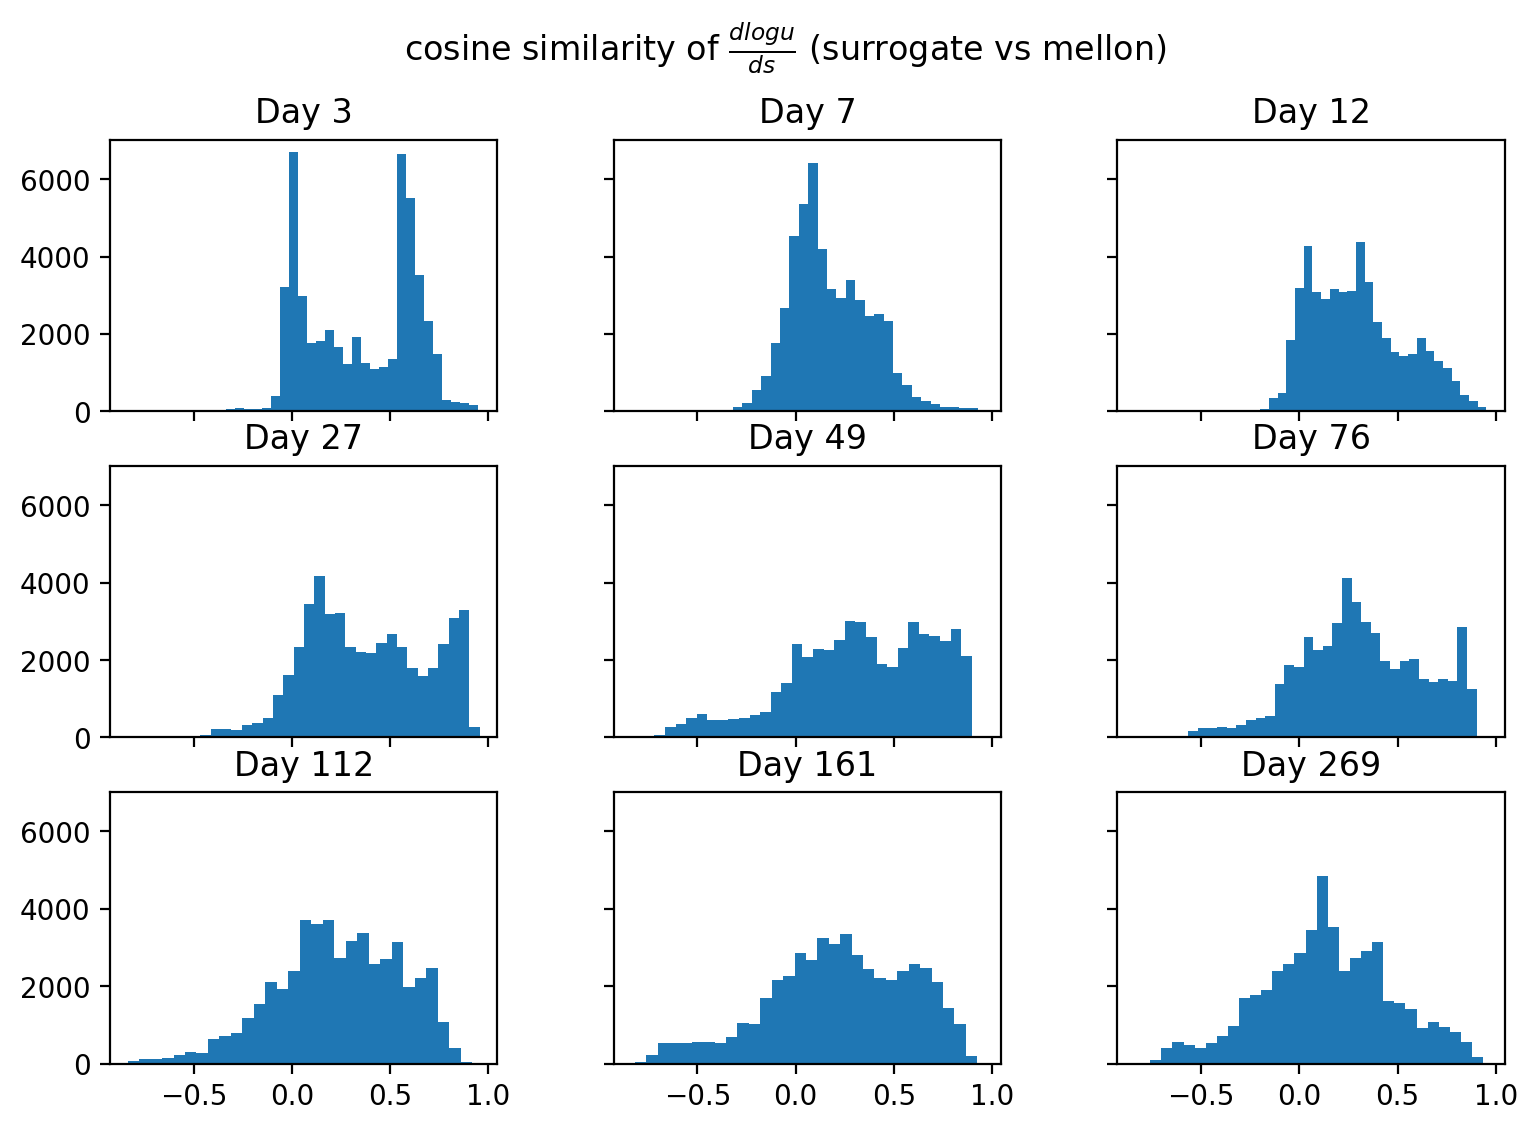

In [71]:
plot_cos(surrogate_mellon_tx_cos, r"cosine similarity of $\frac{dlog u}{ds}$ (surrogate vs mellon)");

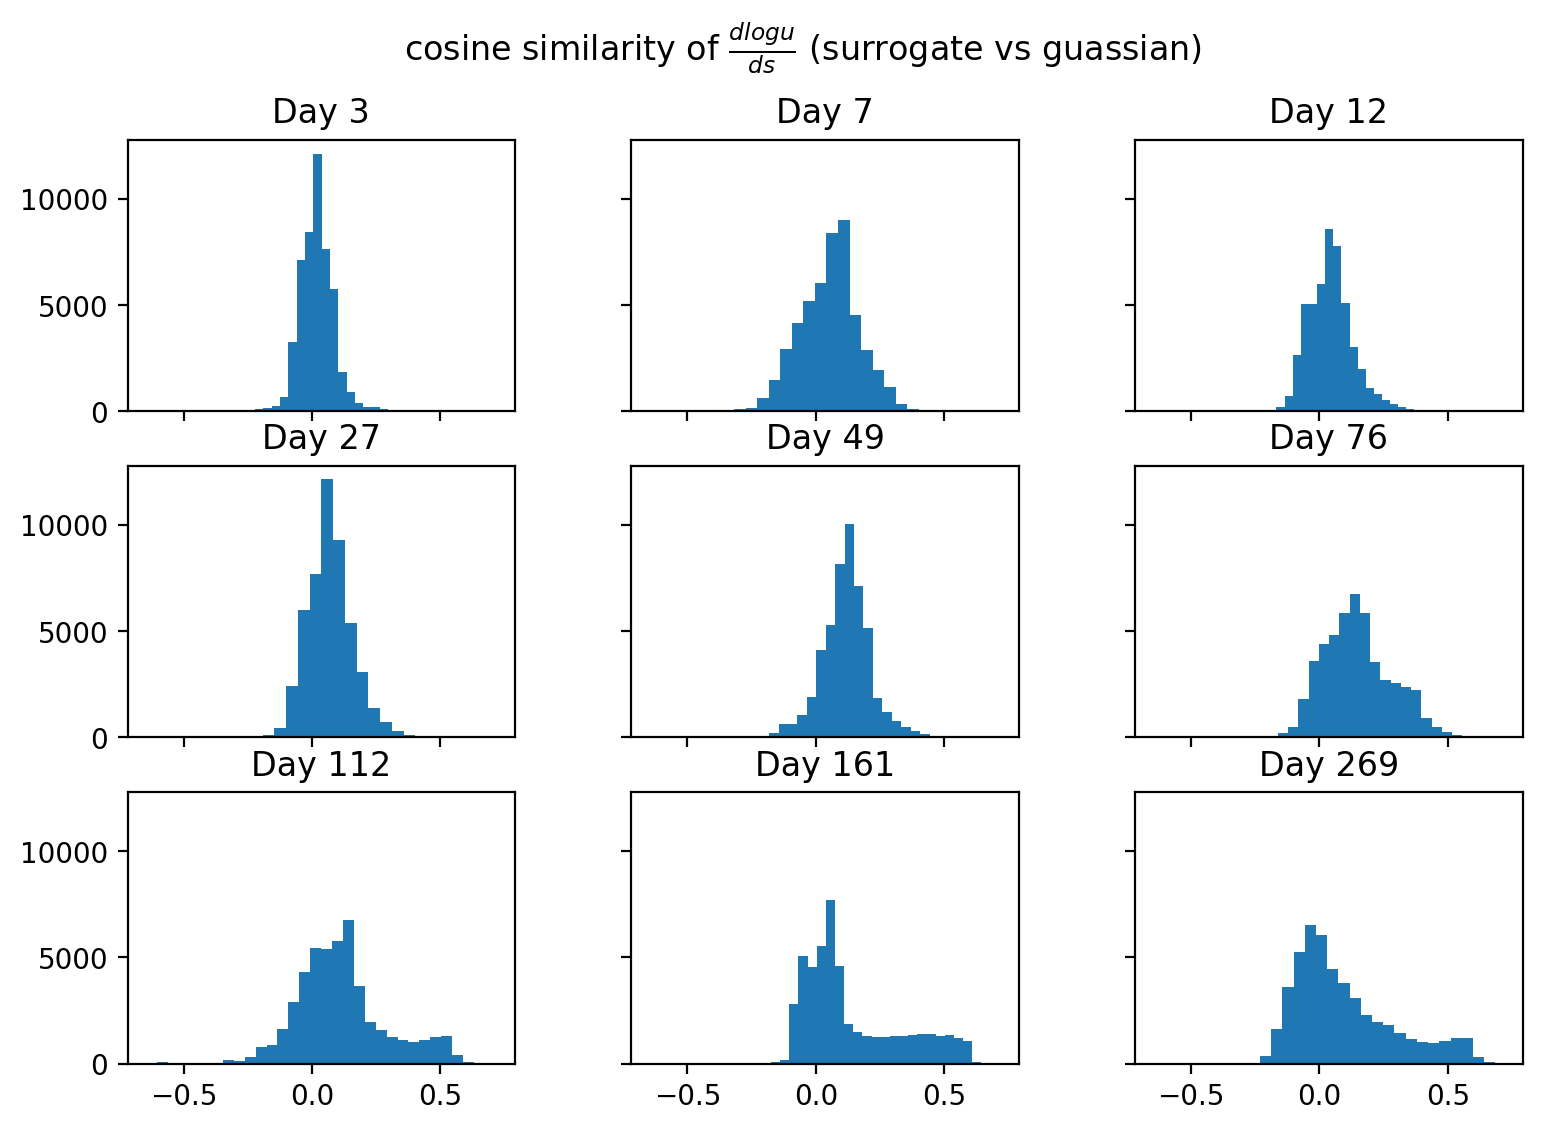

In [36]:
plot_cos(surrogate_manual_tx_cos, r"cosine similarity of $\frac{dlog u}{ds}$ (surrogate vs guassian)");

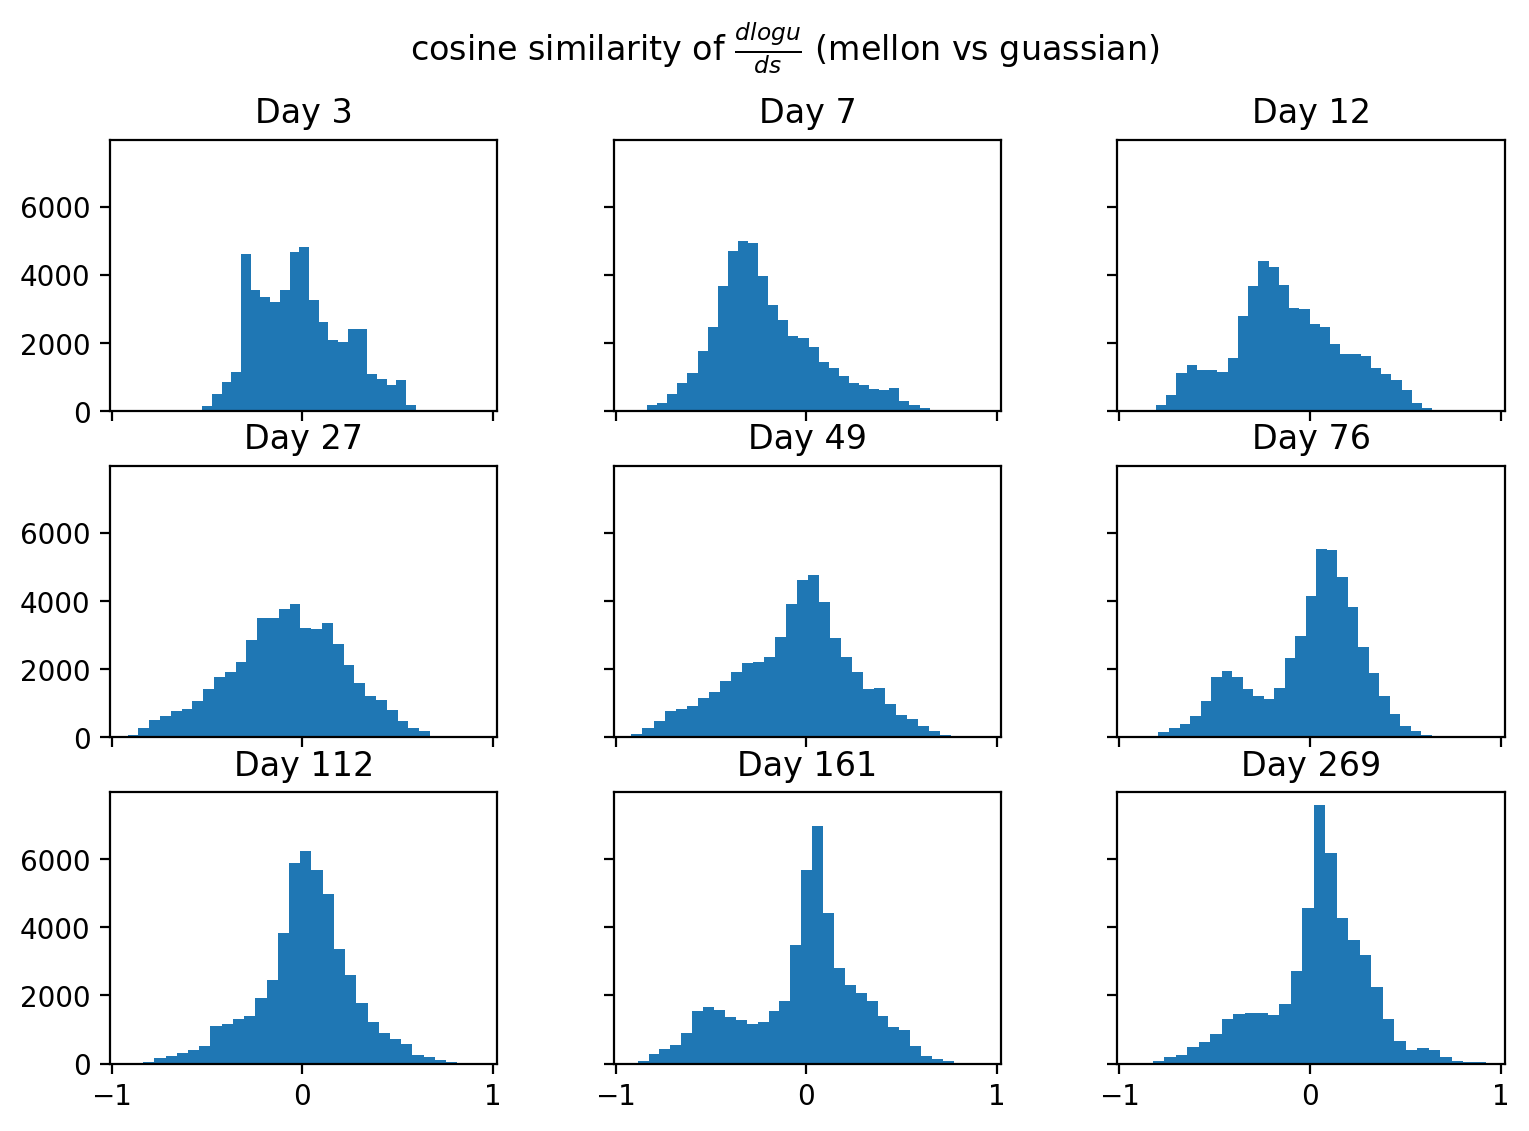

In [37]:
plot_cos(mellon_manual_tx_cos, r"cosine similarity of $\frac{dlog u}{ds}$ (mellon vs guassian)");

In [40]:
log_u_b = np.log(u_b+1e-34)

In [43]:
surrogate_gaussian_r = [pearsonr(logu_ay[i],log_u_b[i])[0] for i in range(9)]

In [54]:
mellon_gaussian_r = [pearsonr(log_u[i],log_u_b[i])[0] for i in range(9)]

prediction of shape (9, 49390)


(<Figure size 2430x200 with 18 Axes>,
 array([<Axes: title={'center': 'Day3_log u\nmin:-7.83e+01\nmax:-9.08e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day7_log u\nmin:-7.83e+01\nmax:-8.47e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day12_log u\nmin:-7.83e+01\nmax:-8.46e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day27_log u\nmin:-7.83e+01\nmax:-7.11e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day49_log u\nmin:-7.83e+01\nmax:-6.64e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day76_log u\nmin:-7.83e+01\nmax:-5.58e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day112_log u\nmin:-7.83e+01\nmax:-5.09e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day161_log u\nmin:-7.83e+01\nmax:-4.83e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day269_log u\nmin:-7.83e+01\nmax:-3.97e+0

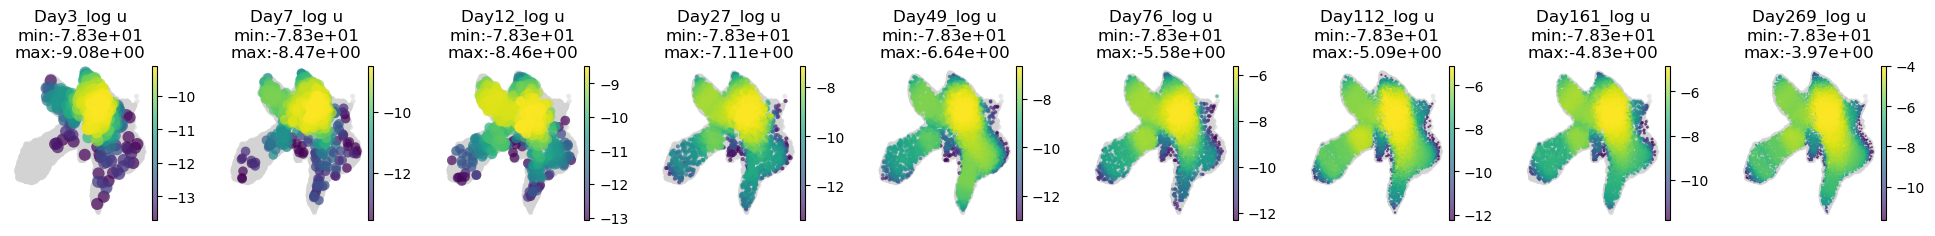

In [46]:
PINN.pl.params_in_umap(adata, log_u_b, param='log u');

prediction of shape (9, 49390)


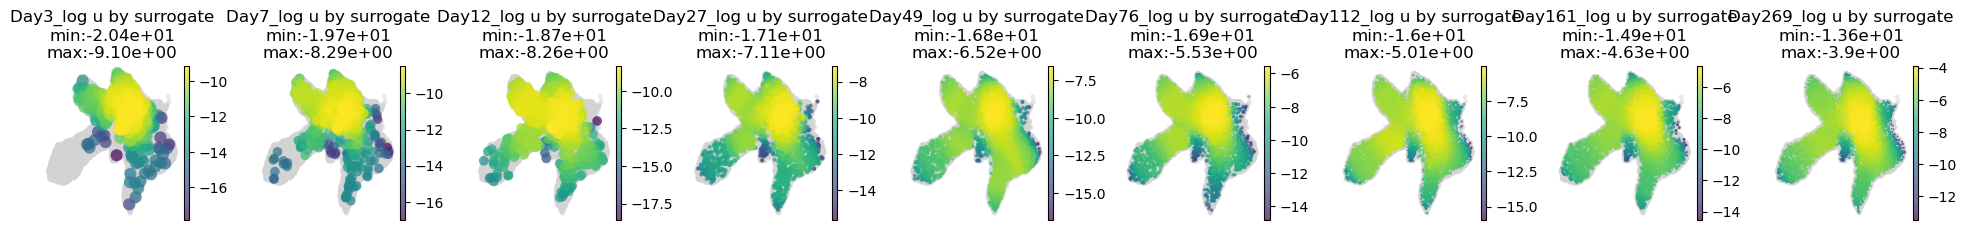

In [72]:
PINN.pl.params_in_umap(adata, logu_ay, param='log u by surrogate');

prediction of shape (9, 49390)


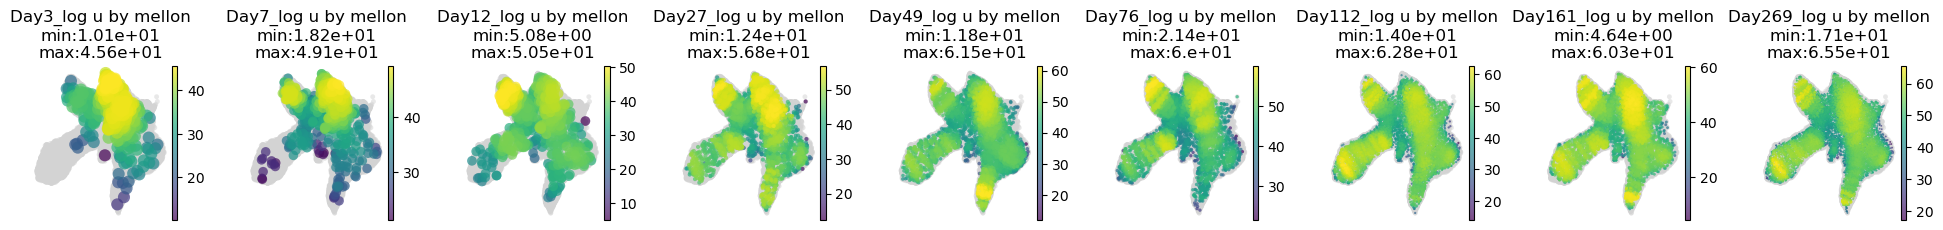

In [56]:
PINN.pl.params_in_umap(adata, log_u, param='log u by mellon');

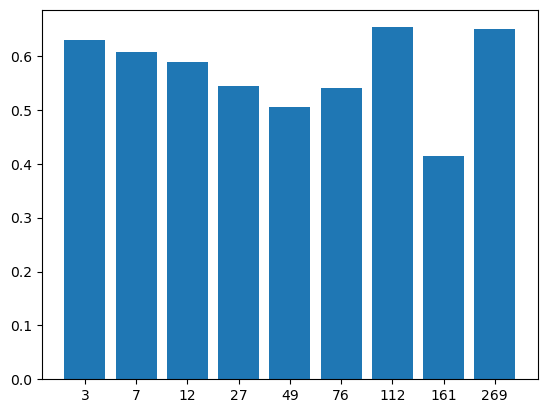

In [74]:
plt.bar(x=range(9),height=surrogate_gaussian_r)
plt.xticks(range(9), timepoints);

([<matplotlib.axis.XTick at 0x154ed03fc670>,
 [Text(0, 0, '3'),
  Text(1, 0, '7'),
  Text(2, 0, '12'),
  Text(3, 0, '27'),
  Text(4, 0, '49'),
  Text(5, 0, '76'),
  Text(6, 0, '112'),
  Text(7, 0, '161'),
  Text(8, 0, '269')])

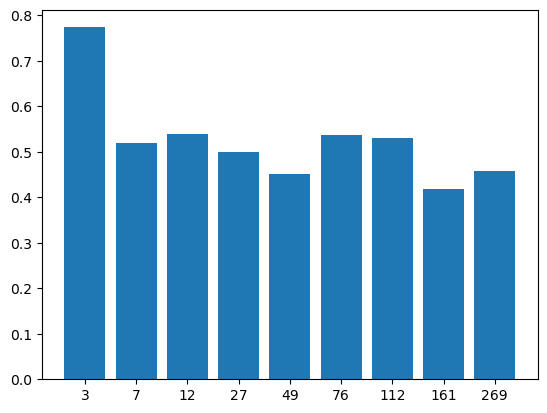

In [55]:
plt.bar(x=range(9),height=mellon_gaussian_r)
plt.xticks(range(9), timepoints)